# Globular Cluster Stream

This example demonstrates how tambora can be used with [galpy](https://docs.galpy.org/en/v1.11.2/) to simulate the formation of a globular cluster tidal stream in the Milky Way.

## Setting up the simulation

Like the [quickstart example](../quickstart.ipynb#quickstart), we start be creating the simulation and adding the external potential.

In [1]:
from tambora.simulation import Sim

stream = Sim()

For the Milky Way, let's use the NFW component of galpy's [MWPotential2014](https://docs.galpy.org/en/latest/tutorials/potentials/milky_way_potentials.html#MWPotential2014) potential and add it to our simulation.

In [2]:
from galpy.potential import MWPotential2014
import astropy.units as u

# create MW potential
host = MWPotential2014[2]
host.turn_physical_on(ro=8*u.kpc, vo=220*u.km/u.s)

# add the potential to the simulation
stream.add_external_pot(host)

Let's say we want to drop the progenitor 15 kpc from the center of the Milky Way and 5 kpc above the disk, with a tangential velocity that is 90% of the circular velocity at that point.

In [3]:
import numpy as np

center_R = 10 * u.kpc # progenitor center radius
center_z = 0 * u.kpc
center_r = np.sqrt(center_R**2 + center_z**2)

# using galpy to calculate circular velocity
center_v = host.vcirc(center_r, quantity=True).to(u.km/u.s) * 0.7 # progentior center speed

Next, we construct the progenitor by sampling **20,000** positions, velocities, and masses from a  $10^8 \text{M}_{\odot}$ King sphere using tambora's initial condition routines with galpy under the hood.

In [4]:
sat_mass = 1e7 * u.Msun # progenitor mass
rtidal = host.rtide(R=center_R, z=0 * u.kpc, M=sat_mass, quantity=True).to(u.kpc)

from tambora.tools import mkKing_galpy
pos, vel, mass = mkKing_galpy(m=sat_mass.value, n = 20000, center_pos = [center_R.value, 0, 0], 
                              center_vel = [0., center_v.value, 0.], W0=2, rt=rtidal.value)

In [5]:
print(f'Each particle has mass {np.mean(mass)} +/- {np.std(mass)} Msun')

Each particle has mass 500.0 +/- 0.0 Msun


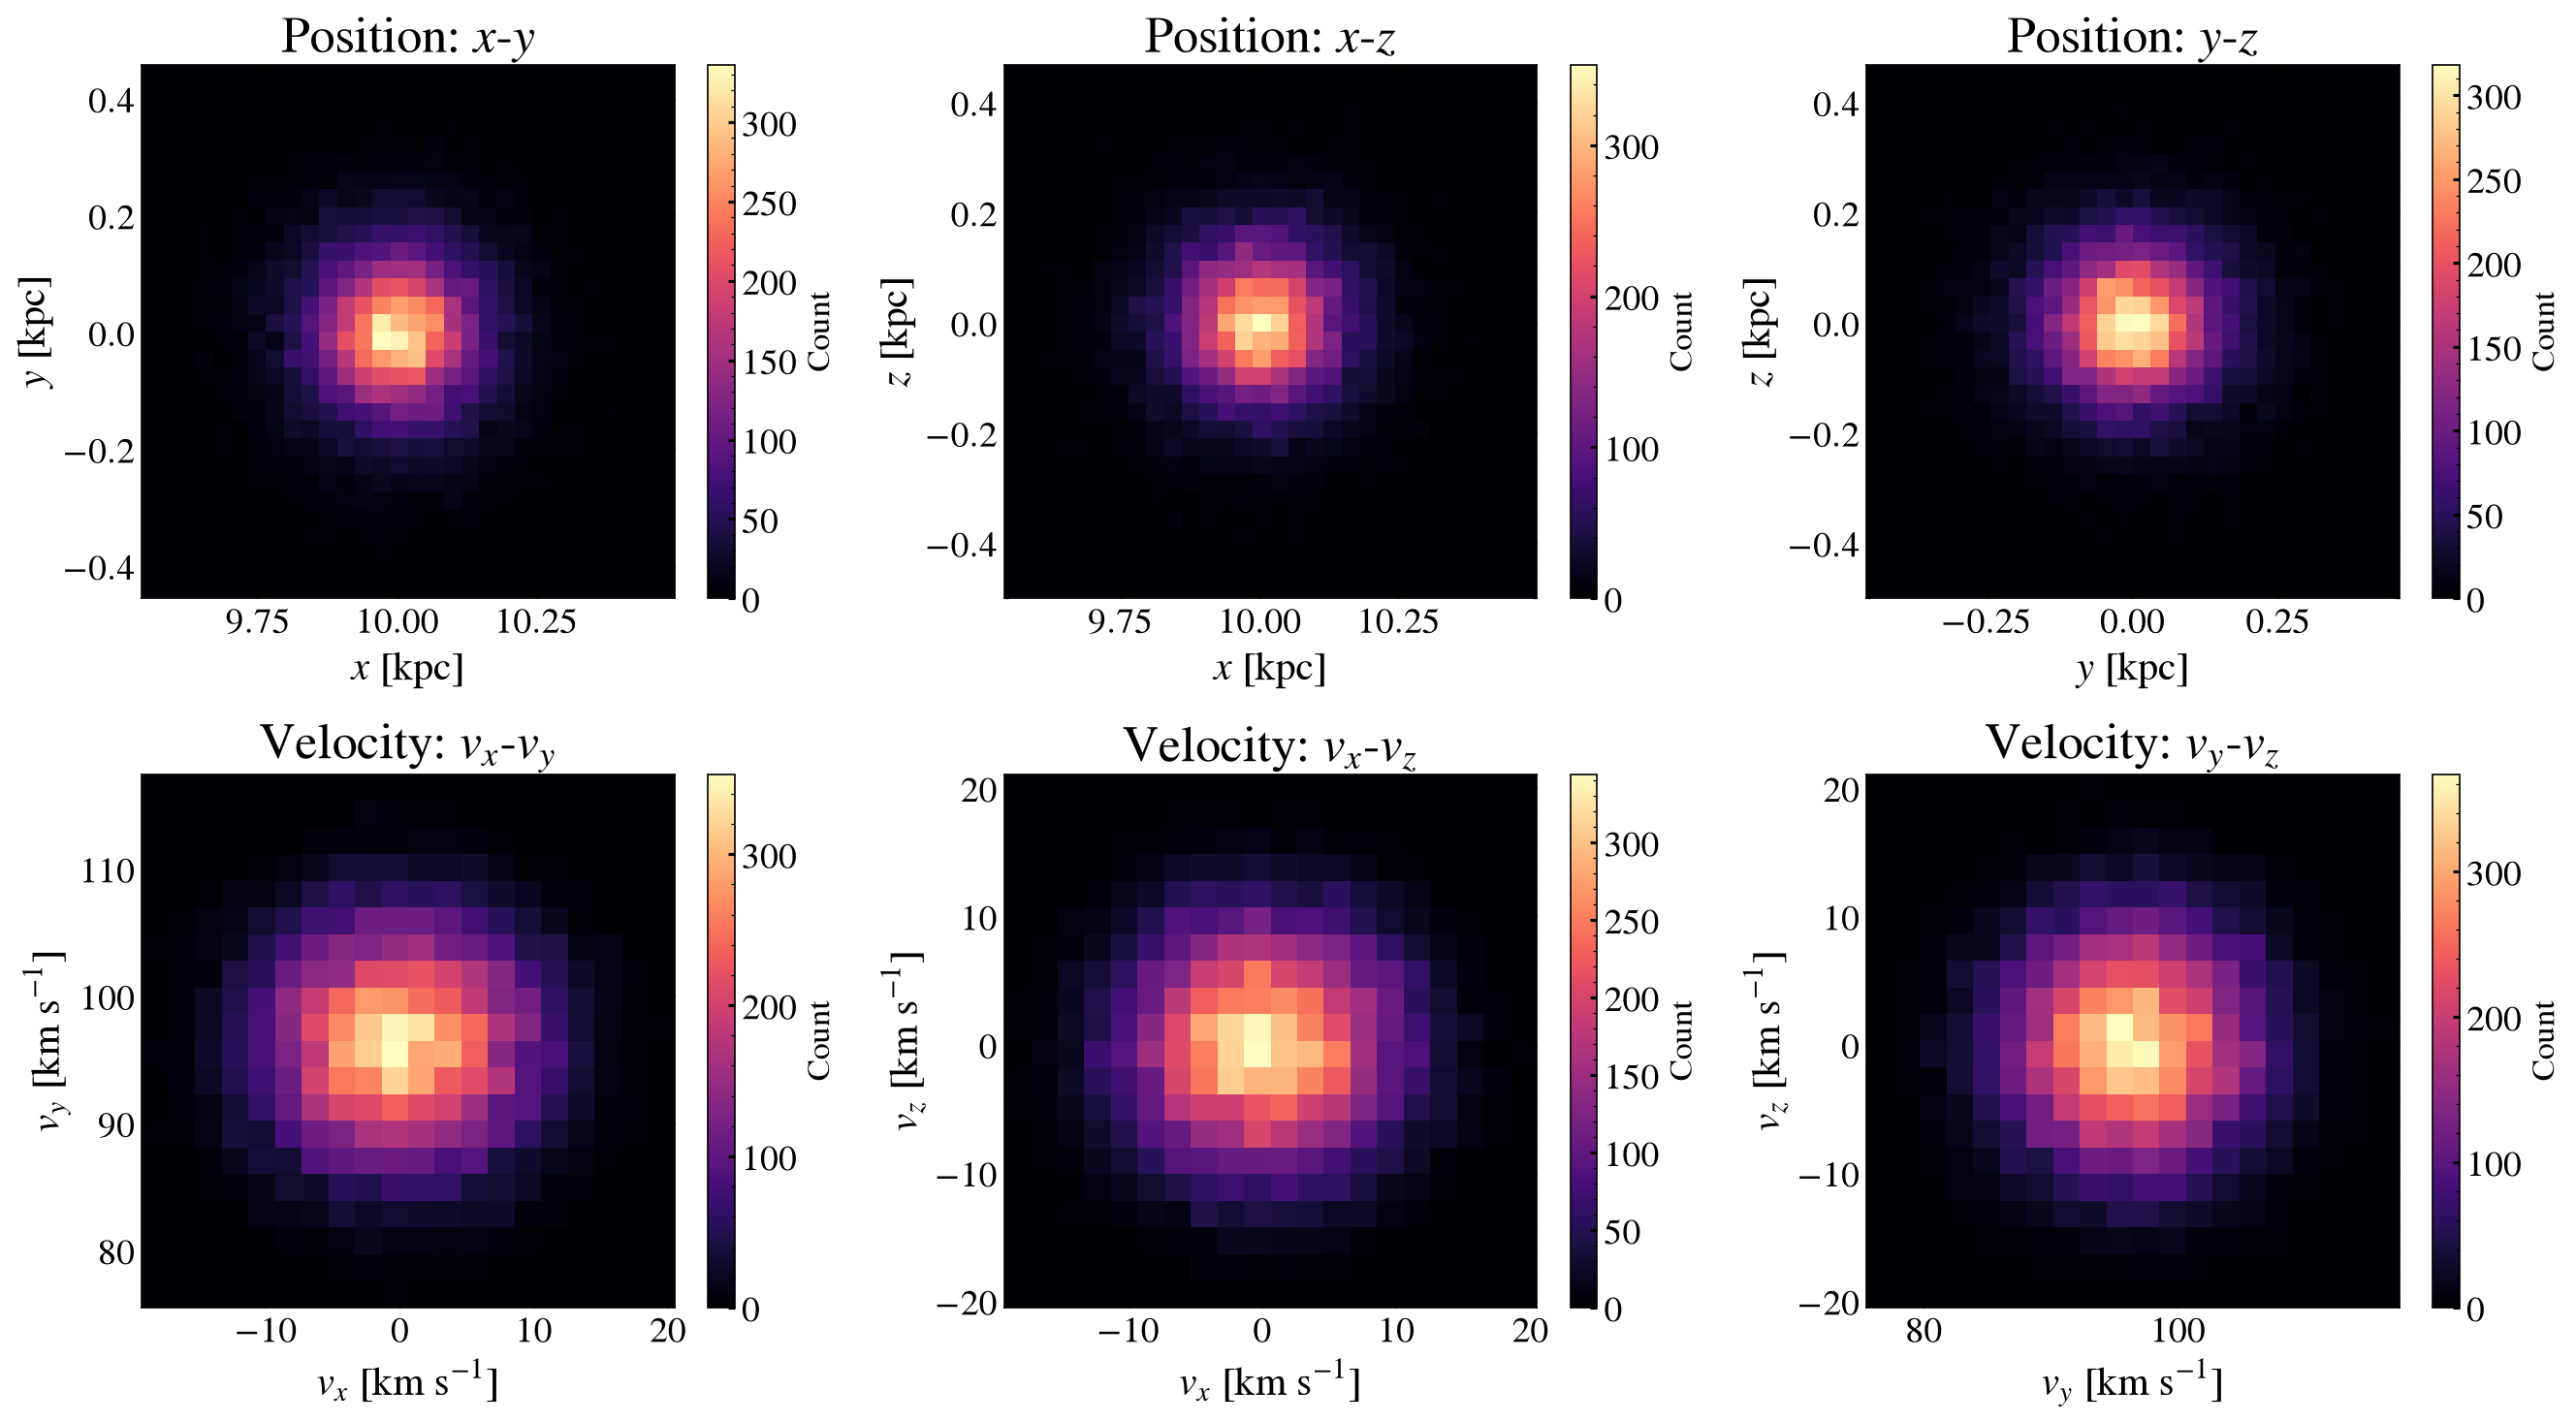

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)

# --- Top row: position projections ---
h_xy = axes[0, 0].hist2d(pos[:, 0], pos[:, 1], bins=30, cmap='magma')
axes[0, 0].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 0].set_ylabel(r'$y$ [kpc]', fontsize=20)
axes[0, 0].set_title('Position: $x$-$y$', fontsize=25)
fig.colorbar(h_xy[3], ax=axes[0, 0], label='Count')

h_xz = axes[0, 1].hist2d(pos[:, 0], pos[:, 2], bins=30, cmap='magma')
axes[0, 1].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 1].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 1].set_title('Position: $x$-$z$', fontsize=25)
fig.colorbar(h_xz[3], ax=axes[0, 1], label='Count')

h_yz = axes[0, 2].hist2d(pos[:, 1], pos[:, 2], bins=30, cmap='magma')
axes[0, 2].set_xlabel(r'$y$ [kpc]', fontsize=20)
axes[0, 2].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 2].set_title('Position: $y$-$z$', fontsize=25)
fig.colorbar(h_yz[3], ax=axes[0, 2], label='Count')

# --- Bottom row: velocity projections ---
h_vxvy = axes[1, 0].hist2d(vel[:, 0], vel[:, 1], bins=20, cmap='magma')
axes[1, 0].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_ylabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_title('Velocity: $v_x$-$v_y$', fontsize=25)
fig.colorbar(h_vxvy[3], ax=axes[1, 0], label='Count')

h_vxvz = axes[1, 1].hist2d(vel[:, 0], vel[:, 2], bins=20, cmap='magma')
axes[1, 1].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_title('Velocity: $v_x$-$v_z$', fontsize=25)
fig.colorbar(h_vxvz[3], ax=axes[1, 1], label='Count')

h_vyvz = axes[1, 2].hist2d(vel[:, 1], vel[:, 2], bins=20, cmap='magma')
axes[1, 2].set_xlabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_title('Velocity: $v_y$-$v_z$', fontsize=25)
fig.colorbar(h_vyvz[3], ax=axes[1, 2], label='Count')

fig.tight_layout()
plt.show()

And we add these particles to the simulation:

In [7]:
stream.add_particles('stars', pos=pos, vel=vel, mass=mass)

We can compare the sampled density profile to the analytic profile:

/geir_data/scr/gabrielspace/tambora/.venv/lib/python3.12/site-packages/galpy/potential/SphericalPotential.py:50: RuntimeWarning: divide by zero encountered in divide
  return (self._r2deriv(r, t=t) - 2.0 * self._rforce(r, t=t) / r) / 4.0 / numpy.pi



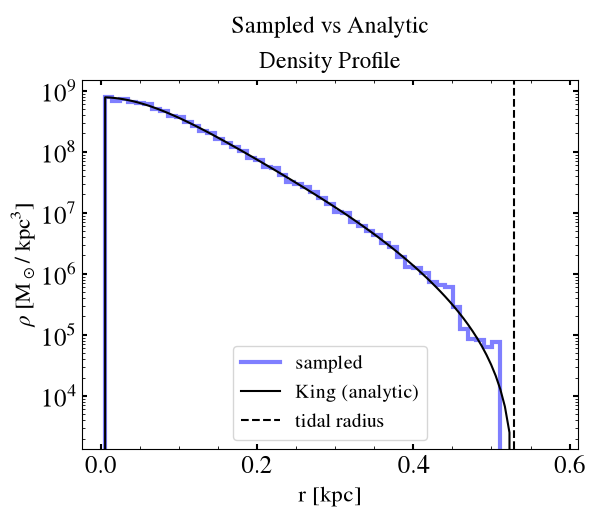

In [8]:
from galpy.potential import KingPotential

kingpot = KingPotential(M=sat_mass, W0=2, rt=rtidal)

# 3D distance of each star from the cluster center
cen = np.median(stream.stars.pos(0), axis=0)
d   = np.linalg.norm(stream.stars.pos(0) - cen, axis=1)

# counts -> volume density via shell volumes
counts, bins = np.histogram(d, bins=50)
r_mid = 0.5 * (bins[:-1] + bins[1:])
shell_vol = 4 * np.pi * r_mid**2 * np.diff(bins)
rho = counts * np.mean(mass) / shell_vol           # M⊙ / kpc^3

rlist = np.linspace(0, 1.1 * rtidal.value, 100) * u.kpc
plt.stairs(rho, bins, color='blue', linewidth=3, label='sampled', alpha=0.5)
plt.plot(rlist, kingpot.dens(rlist, z=0, quantity=True).to(u.Msun / u.kpc**3),
         label='King (analytic)', c='k')
plt.axvline(rtidal.value, ls='--', c='k', label='tidal radius')
plt.xlabel('r [kpc]'); plt.ylabel(r'$\rho$ [M$_\odot$/ kpc$^3$]')
plt.yscale('log'); plt.legend()
plt.title('Sampled vs Analytic\nDensity Profile')
plt.show()

With the particles added, we can do all sorts of fun things like visualize the self-gravity and external forces/accelerations using the helpful accessor methods of {class}`~tambora.simulation.Sim`.

In [9]:
# --- Positions ---------------------------------------- #
xpos = stream.x(0)
ypos = stream.y(0)

# --- Self-Gravity Accelerations ----------------------- #
x_self_acc = stream.self_ax(0, method='falcON', eps=0.01)
y_self_acc = stream.self_ay(0, method='falcON', eps=0.01)

# --- External Field Accelerations --------------------- #
x_ext_acc = stream.external_ax(0)
y_ext_acc = stream.external_ay(0)

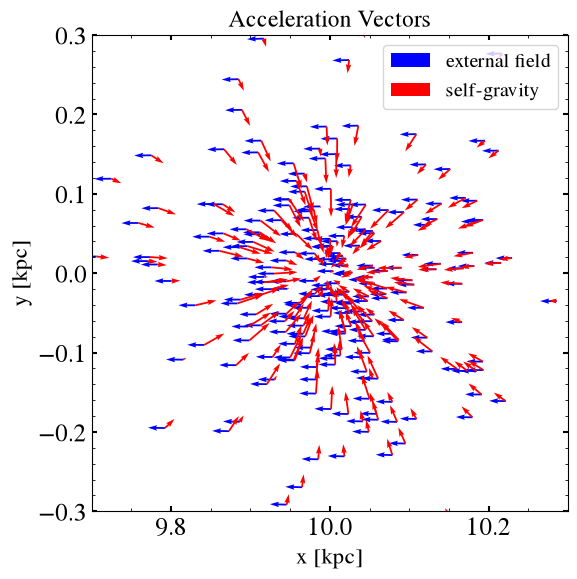

In [10]:
skip_every = 80
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.external_ax(0)[::skip_every], stream.external_ay(0)[::skip_every], 
          alpha=1, color='b', label='external field')
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.self_ax(0, method='falcON', eps=0.01)[::skip_every], 
          stream.self_ay(0, method='falcON', eps=0.01)[::skip_every], 
          alpha=1, color='r', label='self-gravity')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('Acceleration Vectors')
ax.set_aspect('equal')
plt.tight_layout()
plt.xlim(9.7, 10.3)
plt.ylim(-0.3, 0.3)
plt.legend()

plt.show()

## Running the simulation

Next, the `run` method evolves the particles under the influence of self-gravity and the external potential for **1.5 Gyr**. I elect to compute self-gravity with `falcON` here.

Runs in **~2 minutes**

In [11]:
stream.track_boundedness(display='n_unbound')
stream.track_stripping()

In [12]:
stream.run(t_end = 3.0, dt = 0.001, dt_out=0.01, method='falcON', eps=0.01)

100%|██████████| 3000/3000 [04:56<00:00, 10.11it/s, number unbound=12455, |dE/E0|=1.28e+00]


Anddd, **it's a stream!**

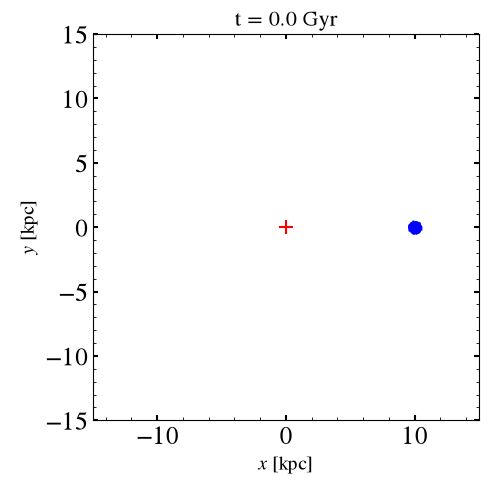

In [13]:
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

# Show every `stride`-th snapshot; raise it to shrink the gif.
stride = 2

# Build the axes/artists once so the layout is fixed for every frame (prevents
# the title/labels getting clipped) and only update what changes per frame.
fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_aspect('equal')
ax.set_xlabel(r'$x$ [kpc]', fontsize=14)
ax.set_ylabel(r'$y$ [kpc]', fontsize=14)
ax.scatter(0, 0, s=100, c='r', marker='+', zorder=3)   # progenitor center
bnd_pts = ax.scatter([], [], s=1.0, c='blue', alpha=0.5)
unbd_pts = ax.scatter([], [], s=1.0, c='r', alpha=0.5)
title = ax.set_title('', fontsize=16)
fig.tight_layout()

def update(frame):
    i = frame * stride
    bnd_pts.set_offsets(np.column_stack([stream.x(i)[stream.bound(i)], stream.y(i)[stream.bound(i)]]))
    unbd_pts.set_offsets(np.column_stack([stream.x(i)[~stream.bound(i)], stream.y(i)[~stream.bound(i)]]))
    title.set_text(f't = {stream.times[i]:.1f} Gyr')
    return bnd_pts, unbd_pts, title

# frames spans every snapshot, so the gif always covers the full run.
ani = FuncAnimation(fig, update, frames=len(stream.times) // stride, interval=100)

# Real .gif via Pillow (no ffmpeg); embedded as image/gif in the saved output so
# it ships with nb_execution_mode="off". Re-run locally + commit to refresh.
ani.save('GC_stream_evolution_2.gif', writer=PillowWriter(fps=12))
plt.close(fig)

Image('GC_stream_evolution_2.gif', embed=True)

In [ ]:
# fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
# ax.set_xlim(-15, 15)
# ax.set_ylim(-15, 15)
# #ax.scatter(0, 0, s=100, c='r', marker='+', zorder=3)   # progenitor center
# pts = ax.scatter([], [], s=1.0, c='k', alpha=0.5)
# #title = ax.set_title('', fontsize=16)
# fig.tight_layout()
# ax.set_axis_off()

# def update(frame):
#     i = frame * stride
#     pts.set_offsets(np.column_stack([stream.x(i), stream.y(i)]))
#     #title.set_text(f't = {stream.times[i]:.1f} Gyr')
#     return pts, title

# # frames spans every snapshot, so the gif always covers the full run.
# ani = FuncAnimation(fig, update, frames=len(stream.times) // stride, interval=100)

# # Real .gif via Pillow (no ffmpeg); embedded as image/gif in the saved output so
# # it ships with nb_execution_mode="off". Re-run locally + commit to refresh.
# ani.save('GC_stream_evolution_no_axes.gif', writer=PillowWriter(fps=12))
# plt.close(fig)

In [14]:
bound_com = []
for t in stream.times:
    pos = stream.pos(t)[stream.bound(t)]
    mass = stream.mass[stream.bound(t)]
    com = (np.sum(mass * pos.T, axis=1) / np.sum(mass)).T
    bound_com.append(com)
bound_com = np.array(bound_com)

from scipy.signal import argrelextrema
com_r = np.linalg.norm(bound_com, axis=1)
apo_args = argrelextrema(com_r, np.greater)
peri_args = argrelextrema(com_r, np.less)

apo_ts = stream.times[apo_args]
peri_ts = stream.times[peri_args]

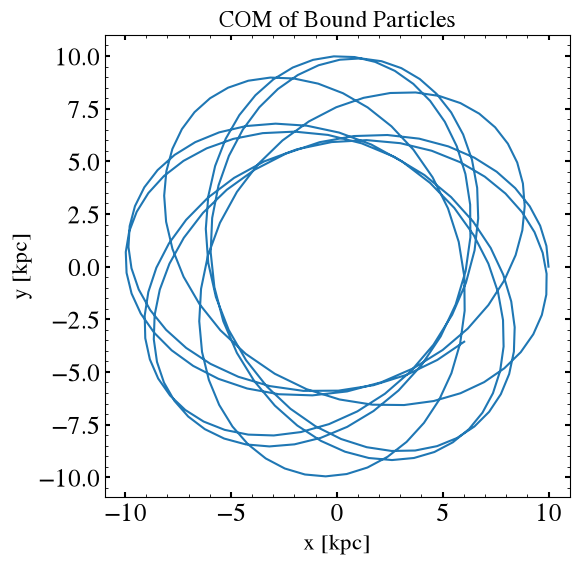

In [15]:
plt.figure(figsize=(6,6))
plt.plot(bound_com[...,0], bound_com[:,1])
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title('COM of Bound Particles')
plt.show()


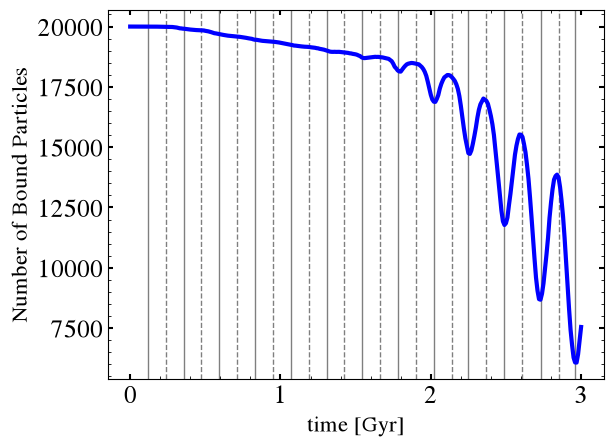

In [29]:
[plt.axvline(peri_t, c='k', alpha=0.5, zorder=0, lw=1) for peri_t in peri_ts]
[plt.axvline(apo_t, c='k', alpha=0.5, ls='--', zorder=0, lw=1) for apo_t in apo_ts]
plt.plot(stream.times, np.sum(stream.bound(), axis=1), lw=3, c='blue')
plt.xlabel('time [Gyr]')
plt.ylabel('Number of Bound Particles')
plt.show()

Text(0, 0.5, 'Number of Stars Stripped')

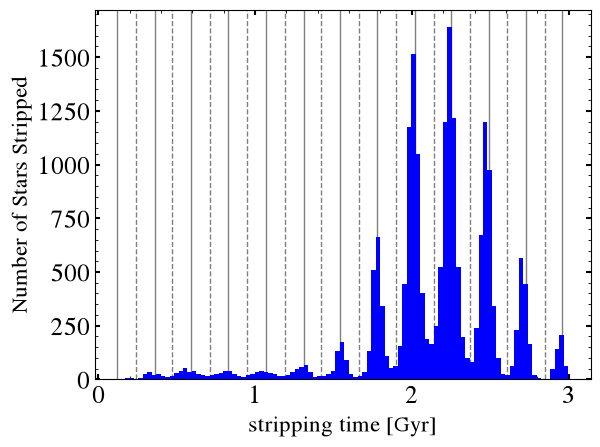

In [30]:
[plt.axvline(peri_t, c='k', alpha=0.5, zorder=0, lw=1.) for peri_t in peri_ts]
[plt.axvline(apo_t, c='k', alpha=0.5, ls='--', zorder=0, lw=1.) for apo_t in apo_ts]
plt.hist(stream.tstrip_first, bins=100, color='blue', alpha=1.0, zorder=10)

plt.xlabel('stripping time [Gyr]')
plt.ylabel('Number of Stars Stripped')

Text(0, 0.5, 'Number of Particles')

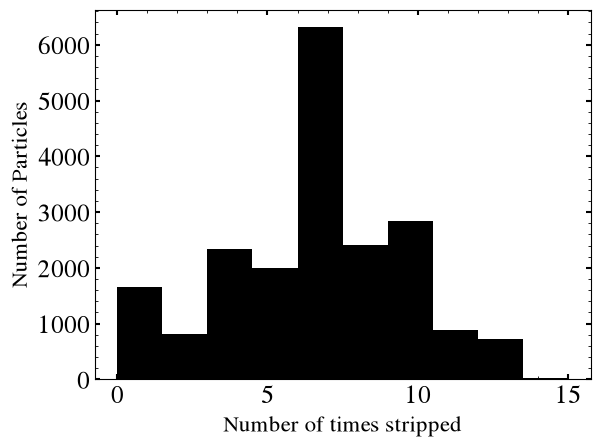

In [19]:
plt.hist(stream.n_strip, bins=10, color='k')
plt.xlabel('Number of times stripped')
plt.ylabel('Number of Particles')

Radius (from bound COM) of stripping as a function of time

In [20]:
stream.strip_pos

array([[ 5.52692744e+00, -3.13078556e+00,  1.20022819e-01],
       [ 5.27909267e+00,  5.29429735e+00,  4.41950837e-02],
       [-6.32999136e+00, -2.50029550e+00,  1.97979418e-02],
       ...,
       [ 5.88538504e+00, -1.54398133e+00, -6.76366492e-03],
       [-3.36877545e+00,  7.99830669e+00, -1.05961950e-01],
       [ 5.85591556e+00,  3.45112563e-01, -7.16284866e-02]],
      shape=(20000, 3))

In [21]:
# bound positions at time of stripping
r_strip = []
for tstrip, strip_pos in zip(stream.tstrip_last, stream.strip_pos):
    bound_pos = stream.pos(tstrip)[stream.bound(tstrip)]
    bound_mass = stream.mass[stream.bound(tstrip)]
    bound_com = (np.sum(bound_mass * bound_pos.T, axis=1) / np.sum(bound_mass)).T
    disp = bound_com - strip_pos
    disp_r = np.linalg.norm(disp)
    r_strip.append(disp_r)
# displacement from COM at time of stripping

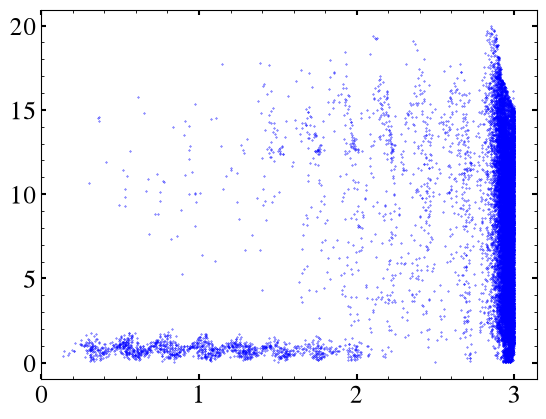

In [22]:
plt.scatter(stream.tstrip_last, r_strip, s=0.1, c='blue')

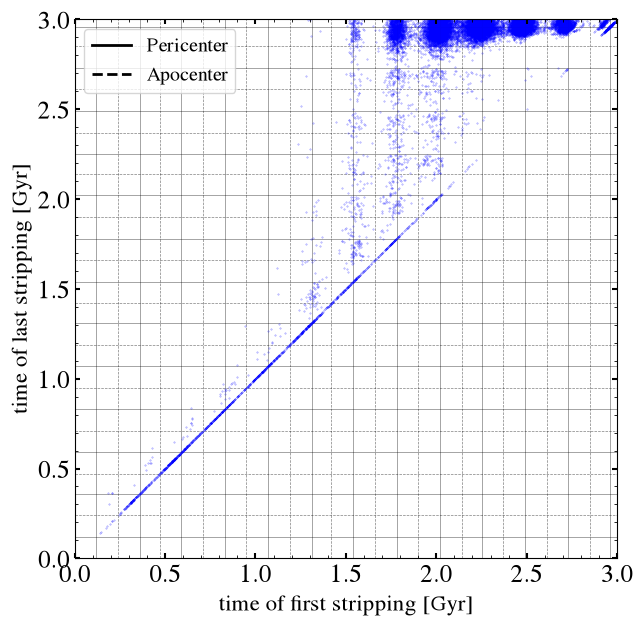

In [25]:
fig, ax = plt.subplots(figsize=(7,7))
[ax.axvline(peri_t, c='k', alpha=0.5, zorder=0, lw=0.5) for peri_t in peri_ts]
[ax.axhline(peri_t, c='k', alpha=0.5, zorder=0, lw=0.5) for peri_t in peri_ts]
[ax.axvline(apo_t, c='k', alpha=0.5, ls='--', zorder=0, lw=0.5) for apo_t in apo_ts]
[ax.axhline(apo_t, c='k', alpha=0.5, ls='--', zorder=0, lw=0.5) for apo_t in apo_ts]
ax.scatter(stream.tstrip_first, stream.tstrip_last, s=0.1, alpha=0.5, color='blue')
ax.set_xlabel('time of first stripping [Gyr]')
ax.set_ylabel('time of last stripping [Gyr]')

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='k', lw=2),
                Line2D([0], [0], color='k', lw=2, ls='--')]

# fig, ax = plt.subplots()
# lines = ax.plot(data)
ax.legend(handles=custom_lines, labels=['Pericenter', 'Apocenter'])

ax.set_xlim(0, 3.0)
ax.set_ylim(0, 3.0)
plt.show()

## Checking Performance

We can check how well energy is conserved in a few different ways. We can check using the values calculated during integration (fastest):

/geir_data/scr/gabrielspace/tambora/tambora/simulation/simulation.py:1174: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



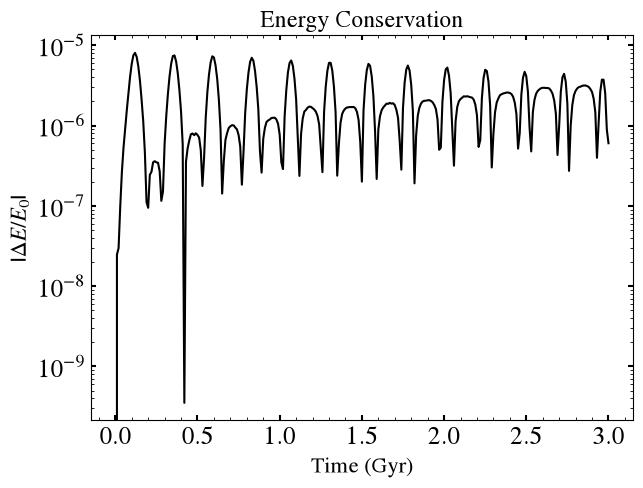

In [24]:
stream.plot_energy_diagnostic()

We can also check conservation of energy with a different method for calculating the self-gravity potential that is more precise (direct summation, slower). This allows us to ensure 

In [ ]:
# direct summation is expensive, so only 
# calculate at 5 snapshots. Runs in ~5.5 minutes

#stream.plot_energy_diagnostic(method='direct_C', eps=0.01, nsnap=5)